#### Chair의 이미지 해상도를 통일하여 적용

In [1]:
# chair의 1번 이미지
from PIL import Image
import numpy as np

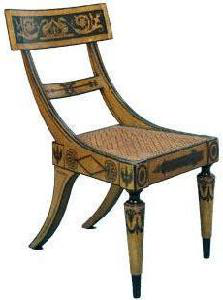

In [3]:
img = Image.open('../Data/chair/chair/image_0001.jpg')
img

In [4]:
np.array(img).shape

(300, 223, 3)

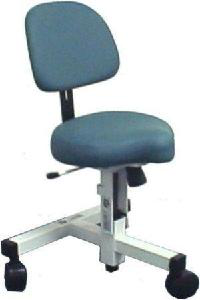

In [5]:
img = Image.open('../Data/chair/chair/image_0002.jpg')
img

In [6]:
np.array(img).shape

(300, 200, 3)

> 이미지 해상도가 일정하지 않음    
> 전체 이미지의 해상도의 최댓값 혹은 평균값으로 적용해보자    
> 너무 작은 이미지가 커지지 않도록 평균값을 적용

#### Chair의 전체 이미지 평균 해상도를 구하자

In [7]:
import glob

In [8]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob('../Data/chair/chair/*.jpg')):
    img = np.array(Image.open(file), dtype=np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

In [11]:
print(f'Chair의 너비 평균 해상도 : {np.mean(widthRatio)}')
print(f'Chair의 높이 평균 해상도 : {np.mean(heightRatio)}')

Chair의 너비 평균 해상도 : 229.65
Chair의 높이 평균 해상도 : 297.31666666666666


#### Laptop의 전체 이미지 평균 해상도를 구하자

In [12]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob('../Data/laptop/*.jpg')):
    img = np.array(Image.open(file), dtype=np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

In [13]:
print(f'Laptop의 너비 평균 해상도 : {np.mean(widthRatio)}')
print(f'Laptop의 높이 평균 해상도 : {np.mean(heightRatio)}')

Laptop의 너비 평균 해상도 : 295.03333333333336
Laptop의 높이 평균 해상도 : 267.1


> 너비 : 264, 높이 : 284로 정함!

----
#### Chair 이미지 해상도 및 흑백 이미지 변경

In [15]:
i = 1

for file in sorted(glob.glob('../Data/chair/chair/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((264, 284), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/Chair_New/image_{i:02}.jpg', 'JPEG')
    i+=1

----
#### Laptop 이미지 해상도 및 흑백 이미지 변경

In [16]:
i = 1

for file in sorted(glob.glob('../Data/laptop/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((264, 284), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/Laptop_New/image_{i:02}.jpg', 'JPEG')
    i+=1

----
#### Chair Image를 Numpy로 변경하기

In [17]:
number_of_data = 60
img_width_size = 264
img_height_size = 284

In [19]:
chairData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype=np.int32
).reshape(
    number_of_data, img_height_size, img_width_size
)
chairData.shape

(60, 284, 264)

In [25]:
i = 0

for file in sorted(glob.glob('../Data/Chair_New/*.jpg')):
    img = np.array(Image.open(file), dtype=np.int32)
    chairData[i, :, :] = img
    i+=1
chairData.shape

(60, 284, 264)

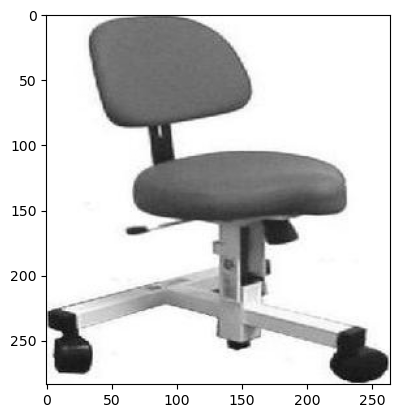

In [26]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(chairData[1].reshape(284, 264), cmap='gray')
plt.show()

----
#### Laptop 이미지를 Numpy array로 변경

In [28]:
laptopData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype=np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
laptopData.shape

(60, 284, 264)

In [30]:
i = 0

for file in sorted(glob.glob('../Data/Laptop_New/*.jpg')):
    img = np.array(Image.open(file), dtype=np.int32)
    laptopData[i, :, :] = img
    i+=1
laptopData.shape 

(60, 284, 264)

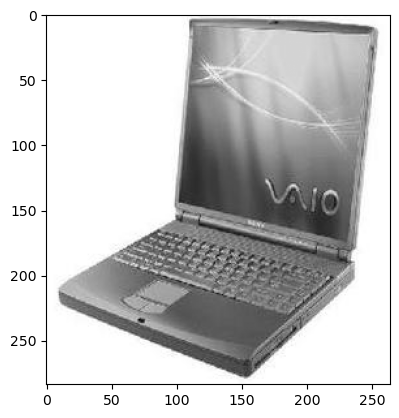

In [37]:
plt.imshow(laptopData[6].reshape(284, 264), cmap='gray')
plt.show()

----
#### Train Data로 합치기

In [39]:
train = np.concatenate(
    [
        chairData, 
        laptopData
    ]
)
train.shape

(120, 284, 264)

---
#### 타겟 데이터 만들기

In [40]:
target = np.concatenate(
    [
        np.zeros(60), np.ones(60)
    ]
)
target.shape

(120,)

---
#### CNN으로 정확도 측정하기
- 데이터 정규화 및 채널 추가
- Train과 Test 분리
- CNN 만들기
- 시각화
- 평가(evaluate로 Train과 Test 평가)

In [171]:
from tensorflow import keras
from sklearn.model_selection import train_test_split
train = train.reshape(-1, 284, 264, 1) / 255.0

train_input, test_input, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

In [172]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(96, 284, 264, 1) (96,)
(24, 284, 264, 1) (24,)


----
#### 모델 생성

In [298]:
model = keras.Sequential()

#### CNN 합성곱 생성

In [299]:
model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation='relu',
        padding='same',
        input_shape=(284, 264, 1)
    )
)
model.add(
    keras.layers.MaxPooling2D(2)
)

In [300]:
model.add(
    keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation='relu',
        padding='same',
    )
)
model.add(
    keras.layers.MaxPooling2D(2)
)

#### Layer 생성

In [301]:
# 입력층
model.add(
    keras.layers.Flatten()
)

# 은닉층
model.add(
    keras.layers.Dense(100, activation='relu')
)
model.add(
    keras.layers.Dense(60, activation='relu')
)
model.add(
    keras.layers.Dense(40, activation='relu')
)
model.add(
    keras.layers.Dropout(0.5)
)

model.add(
    keras.layers.Dense(20, activation='relu')
)

model.add(
    keras.layers.Dropout(0.5)
)

# 출력층
model.add(
    keras.layers.Dense(1, activation='sigmoid')
)

In [302]:
model.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_58 (Conv2D)              │ (None, 284, 264, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 142, 132, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 142, 132, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 71, 66, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_30 (Flatten)            │ (None, 299904)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_126 (Dense)               │ (None, 100)            │    29,990,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 40)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_129 (Dense)               │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_130 (Dense)               │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,018,657 (114.51 MB)

 Trainable params: 30,018,657 (114.51 MB)

 Non-trainable params: 0 (0.00 B)

In [303]:
# 손실함수
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_cl_cnn.keras')
earlystopping_cb = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

In [304]:
history = model.fit(
    train_input,
    train_target,
    epochs=50,
    validation_data=(test_input, test_target),
    callbacks=[checkpoint_cb, earlystopping_cb]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5000 - loss: 1.3874 - val_accuracy: 0.4583 - val_loss: 0.8075
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5417 - loss: 1.0392 - val_accuracy: 0.4583 - val_loss: 0.7466
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3958 - loss: 0.7897 - val_accuracy: 0.4583 - val_loss: 0.7022
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4062 - loss: 0.6999 - val_accuracy: 0.4583 - val_loss: 0.6946
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4688 - loss: 0.6926 - val_accuracy: 0.4583 - val_loss: 0.6936
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5312 - loss: 0.6923 - val_accuracy: 0.4583 - val_loss: 0.6935
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5104 - loss: 0.6931 - val_accuracy: 0.4583 - val_loss: 0.6935
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5104 - loss: 0.6928 - val_accuracy: 0.4583 - val_loss: 0.6935
Epoch 9/50
3/3 ━

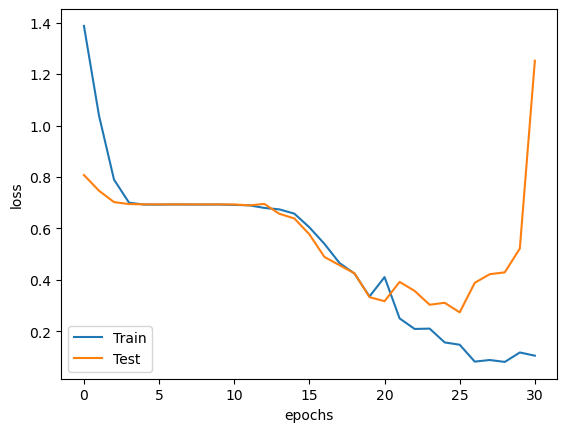

In [305]:
# 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['Train', 'Test'])
plt.show()

In [306]:
model.evaluate(train_input, train_target)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 1.0000 - loss: 0.0119


[0.011926029808819294, 1.0]

In [307]:
model.evaluate(test_input, test_target)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8333 - loss: 0.2736


[0.2735665738582611, 0.8333333134651184]